In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    root_mean_squared_error, r2_score)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("smartphone_price.csv")
df.head()

,phone_id,brand,release_year,ram_gb,storage_gb,battery_mah,screen_size_inch,refresh_rate_hz,processor_score,rear_camera_mp,num_rear_cameras,front_camera_mp,fast_charging_watt,has_5g,has_nfc,build_material,weight_g,os,price_inr
0,PH10000,Apple,2024,18,512,3890,6.57,90,952000,64,3,50.0,100.0,0,1,Glass+Metal,200.0,iOS,76899
1,PH10001,Tecno,2025,2,64,3680,6.15,90,469000,8,2,16.0,10.0,1,0,Plastic,169.0,Android,7199
2,PH10002,Tecno,2021,2,32,3830,6.20,60,324000,16,2,13.0,10.0,0,1,Metal,173.0,Android,4399
3,PH10003,Vivo,2024,6,128,3470,6.33,60,465000,48,2,5.0,25.0,0,0,Metal,156.0,Android,9299
4,PH10004,Sony,2021,8,512,4060,6.50,90,773000,64,3,32.0,100.0,1,1,Glass+Metal,157.0,Android,40899


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   phone_id            3200 non-null   object 
 1   brand               3200 non-null   object 
 2   release_year        3200 non-null   int64  
 3   ram_gb              3200 non-null   int64  
 4   storage_gb          3200 non-null   int64  
 5   battery_mah         3200 non-null   int64  
 6   screen_size_inch    3200 non-null   float64
 7   refresh_rate_hz     3200 non-null   int64  
 8   processor_score     3200 non-null   int64  
 9   rear_camera_mp      3200 non-null   int64  
 10  num_rear_cameras    3200 non-null   int64  
 11  front_camera_mp     3151 non-null   float64
 12  fast_charging_watt  3112 non-null   float64
 13  has_5g              3200 non-null   int64  
 14  has_nfc             3200 non-null   int64  
 15  build_material      3200 non-null   object 
 16  weight

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,3200.0,2022.993438,1.686871,2019.0,2022.0000,2023.00,2024.00,2025.00
ram_gb,3200.0,5.852500,3.662043,2.0,3.0000,4.00,8.00,18.00
storage_gb,3200.0,175.450000,200.025700,32.0,64.0000,128.00,256.00,1024.00
battery_mah,3200.0,3808.906250,417.801811,2800.0,3530.0000,3800.00,4080.00,5260.00
screen_size_inch,3200.0,6.118412,0.282083,5.4,5.9275,6.12,6.31,7.16
refresh_rate_hz,3200.0,93.536250,28.211277,60.0,60.0000,90.00,120.00,144.00
processor_score,3200.0,532199.375000,187326.905242,60000.0,406750.0000,514000.00,642250.00,1305000.00
rear_camera_mp,3200.0,30.152188,31.887261,8.0,13.0000,16.00,48.00,200.00
num_rear_cameras,3200.0,2.077812,0.815147,1.0,2.0000,2.00,3.00,4.00
front_camera_mp,3151.0,13.817518,10.176382,5.0,8.0000,13.00,16.00,50.00


In [7]:
df.describe(include="object")

,phone_id,brand,build_material,os
count,3200,3200,3200,3200
unique,3200,21,4,2
top,PH13183,Samsung,Glass+Metal,Android
freq,1,336,1199,3063


### Drop your columns when,
1. Your column has a lot of unique values
2. Your column is Primary Key column
3. Your column has only one constant value

## Exploratory Data Analysis

#### Target Distribution

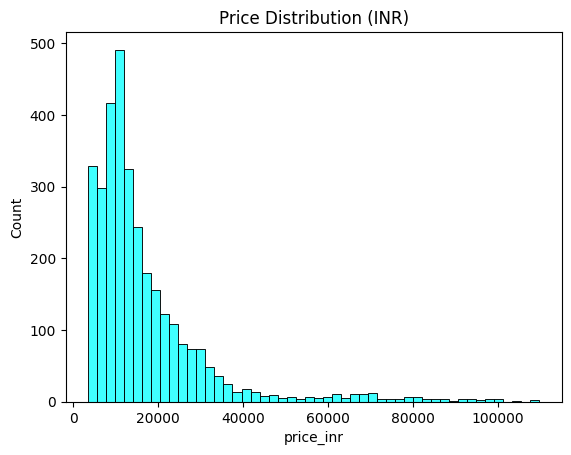

In [8]:
sns.histplot(df["price_inr"],bins=50, color="cyan")
plt.title("Price Distribution (INR)")
plt.show()

### Missing Values

##### Total Missing Values

In [9]:
nulls = df.isna().sum()
nulls[nulls>0]

front_camera_mp       49
fast_charging_watt    88
weight_g              52
dtype: int64

##### Percentage of Missing Values

In [10]:
nulls = df.isna().sum()
nulls[nulls>0]/len(df)*100

front_camera_mp       1.53125
fast_charging_watt    2.75000
weight_g              1.62500
dtype: float64

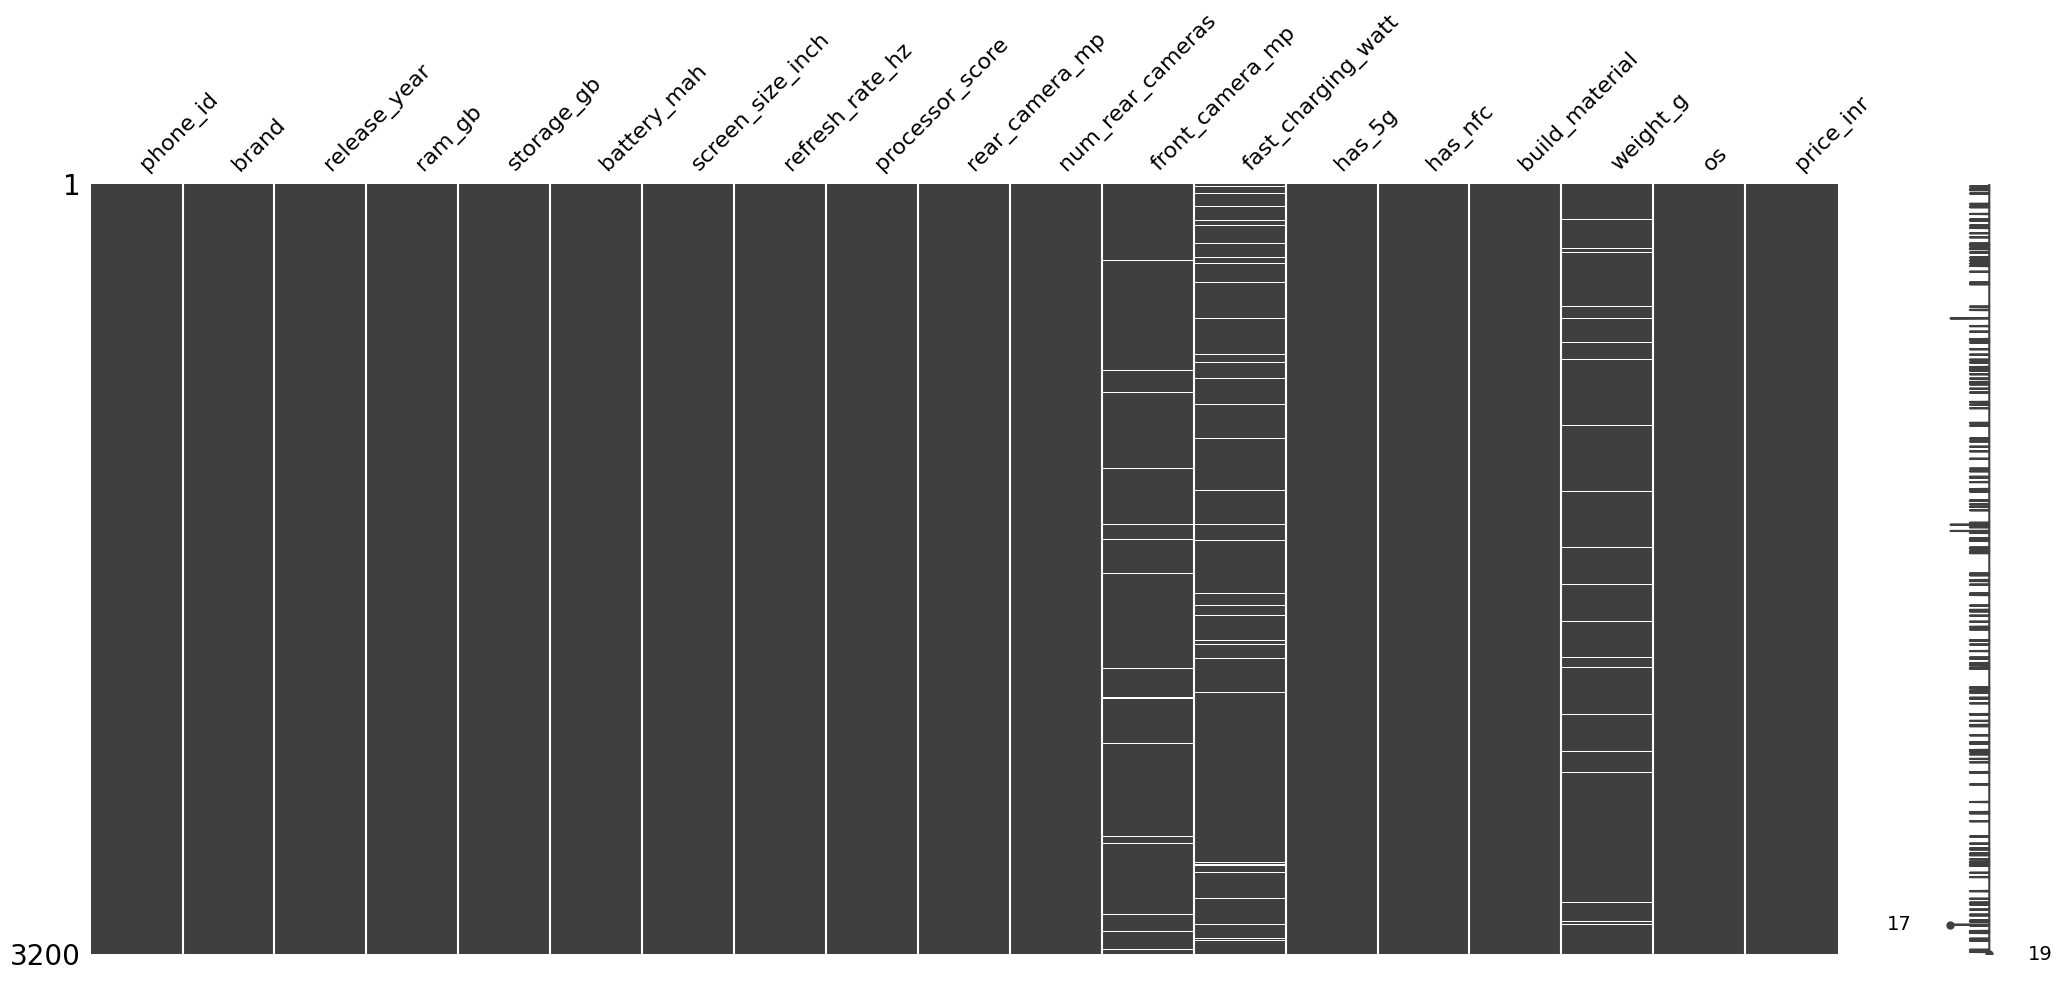

In [11]:
import missingno
missingno.matrix(df);

In [12]:
df[df["weight_g"].isna()].head()

,phone_id,brand,release_year,ram_gb,storage_gb,battery_mah,screen_size_inch,refresh_rate_hz,processor_score,rear_camera_mp,num_rear_cameras,front_camera_mp,fast_charging_watt,has_5g,has_nfc,build_material,weight_g,os,price_inr
82,PH10082,Nothing,2022,12,128,3560,6.15,90,533000,16,3,5.0,25.0,1,0,Metal,NaN,Android,22199
96,PH10096,iQOO,2024,12,512,4490,5.92,144,673000,16,4,13.0,44.0,0,1,Metal,NaN,Android,21199
124,PH10124,OnePlus,2023,12,512,4580,6.06,120,832000,64,3,32.0,65.0,0,1,Glass+Metal,NaN,Android,32299
147,PH10147,Poco,2022,8,64,3960,6.22,60,482000,48,2,13.0,25.0,1,0,Glass+Metal,NaN,Android,11099
204,PH10204,Micromax,2025,2,32,3110,6.37,90,330000,8,1,5.0,15.0,0,0,Plastic,NaN,Android,3899


#### Discovery:
As per my analysis I found out that the **missingness** of columns `'front_camera_mp'`, `'fast_charging_watt'` and `'weight_g'` has no specific reason. Hence, we can conclude that these column's missingness type is **MCAR** .

#### Correlation Heatmap (Numeric Features)

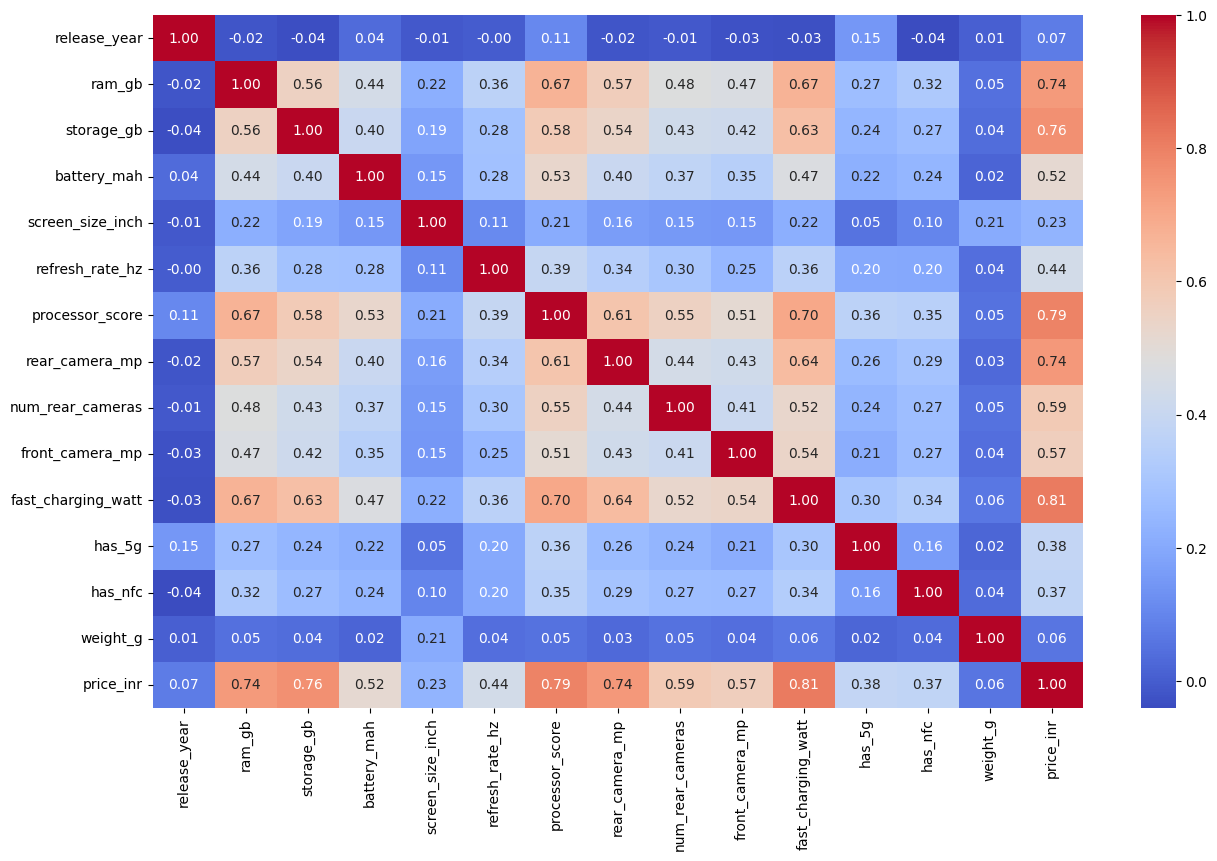

In [13]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(15,9))
sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm");

In [14]:
correlation["price_inr"].sort_values(ascending=False)

price_inr             1.000000
fast_charging_watt    0.812046
processor_score       0.794822
storage_gb            0.760492
rear_camera_mp        0.741119
ram_gb                0.736018
num_rear_cameras      0.586869
front_camera_mp       0.568476
battery_mah           0.515270
refresh_rate_hz       0.436563
has_5g                0.382521
has_nfc               0.374729
screen_size_inch      0.233765
release_year          0.073248
weight_g              0.057097
Name: price_inr, dtype: float64

### Feature Engineering & Preprocessing

In [15]:
import datetime

current_year = datetime.datetime.now().year
df["phone_age"] = current_year - df["release_year"]
df["total_camera_mp"] = df["rear_camera_mp"] + df["front_camera_mp"].fillna(0)
df["high_refresh"] = (df["refresh_rate_hz"] >= 90).astype(int)

In [16]:
df.drop("phone_id",axis=1,inplace=True)

In [17]:
target = "price_inr"
X = df.drop(target,axis =1)
y = df[target]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [21]:
categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="missing")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",drop="first"))
])

In [22]:
preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_transformer,num_cols),
    ("cat",categorical_transformer,cat_cols)
])

### Model Building

In [23]:
def evaluation(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) * 100
    print(f"MSE      : {mse:.0f}\nRMSE     : {rmse:.0f}\nR2 Score : {r2:.2f}%")

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_grids = {
    "LinearRegression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"model__alpha": [0.1, 0.5, 1, 5, 10]}),
    "Lasso": (Lasso(max_iter=10000), {"model__alpha": [0.1, 0.5, 1, 5, 10]}),
    "ElasticNet": (ElasticNet(max_iter=10000),
                   {"model__alpha": [0.1, 0.5, 1, 5, 10], "model__l1_ratio": [0.2, 0.5, 0.8]}),
}

best_score, best_name, best_estimator = -np.inf, None, None

In [25]:
for name, (estimator, param_grid) in model_grids.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    if param_grid:
        search = GridSearchCV(pipe, param_grid, cv=kf, scoring="r2", n_jobs=-1)
        search.fit(X_train, y_train)
        score, fitted = search.best_score_, search.best_estimator_
        print(f"{name}: best CV R2 = {score*100:.2f}% | params = {search.best_params_}")
    else:
        scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
        score = scores.mean()
        pipe.fit(X_train, y_train)
        fitted = pipe
        print(f"{name}: mean CV R2 = {score*100:.2f}%")

    if score > best_score:
        best_score, best_name, best_estimator = score, name, fitted

LinearRegression: mean CV R2 = 92.73%
Ridge: best CV R2 = 92.73% | params = {'model__alpha': 0.1}
Lasso: best CV R2 = 92.73% | params = {'model__alpha': 0.5}
ElasticNet: best CV R2 = 90.01% | params = {'model__alpha': 0.1, 'model__l1_ratio': 0.8}


In [26]:
print(f"Selected model: {best_name} (CV R2 = {best_score*100:.2f}%)")

Selected model: Lasso (CV R2 = 92.73%)


In [27]:
final_pipeline = best_estimator
y_pred = final_pipeline.predict(X_test)   # test set touched ONCE, for final reporting only
evaluation(y_test, y_pred)

MSE      : 14212790
RMSE     : 3770
R2 Score : 93.35%


In [28]:
def values(pipeline):
    model_step = pipeline.named_steps["model"]
    print(f"B0:{model_step.intercept_:.0f}")
    print("Coefficients:", end=" ")
    for c in model_step.coef_:
        print(f"{c:.0f},", end=" ")

values(final_pipeline)

B0:14674
Coefficients: 1200, 1028, 2651, -68, 125, 626, 1179, 380, 580, -289, 282, 621, 282, -10, -0, 1372, 185, 3711, 9814, 962, -2662, -3509, -3325, -3802, -326, 2823, 6379, -13, -1594, -829, 8090, 11119, -2718, 297, -0, 1388, -3603, -832, -1139, -474, 33891, 

In [29]:
import joblib
joblib.dump(final_pipeline, "smartphone_price_model.pkl")

['smartphone_price_model.pkl']

In [ ]:
!Streamlit run app.py